In [1]:
# necessary libraries

import pandas as pd
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt

# Load and Prepare the MNIST Dataset

In [2]:
# Load MNIST dataset
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

# Shape of a single image
print("Shape of a single image:", X_train[0].shape)

Shape of a single image: (28, 28)


In [3]:
# Normalize pixel values to range [0,1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [4]:
# Add channel dimension for CNN (28,28) → (28,28,1)
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

# One-hot encode labels
Y_train = to_categorical(Y_train, 10)
Y_test = to_categorical(Y_test, 10)

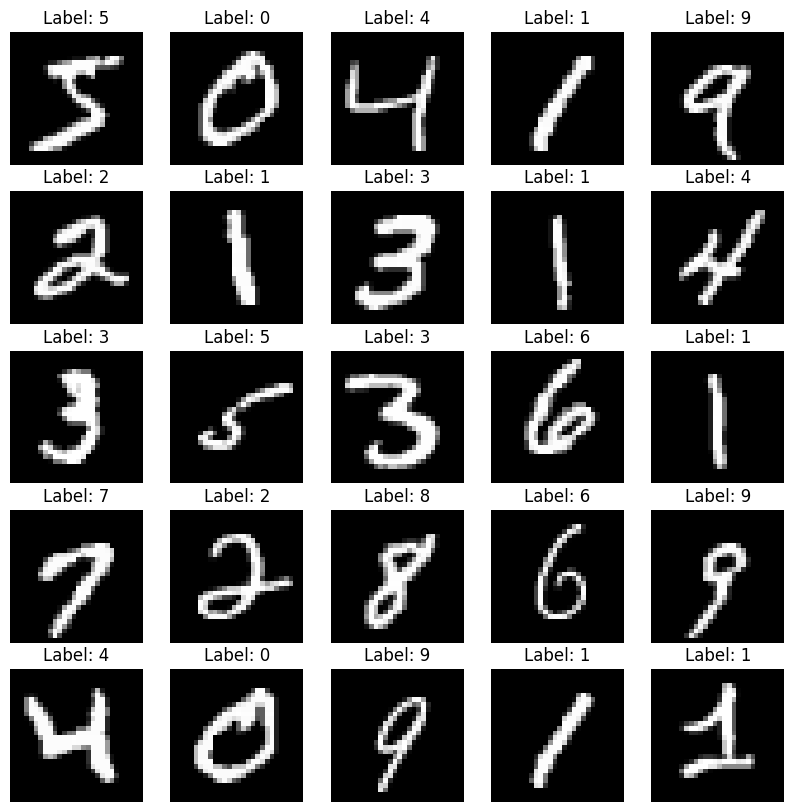

In [5]:
# Display some sample images with their true labels
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    # Assuming Y_train is one-hot encoded, get the original label
    plt.title(f"Label: {np.argmax(Y_train[i])}")
    plt.axis('off')
plt.show()

**Why normalization?**

To make training more stable, avoid exploding/vanishing gradients, and speed up convergence.

# Model Building

In [6]:
# Build Model
model = Sequential()

# Convolution layer
model.add(Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)))

# Max Pooling
model.add(MaxPooling2D(pool_size=(2,2)))

# Another convolution layer
model.add(Conv2D(64, (3,3), activation="relu"))

# Another pooling
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())  # Flatten pooled feature maps
model.add(Dense(128, activation="relu"))  # Fully connected
model.add(Dense(10, activation="softmax"))  # Output layer

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Q: How does kernel size affect output shape?**

Larger kernels reduce spatial dimensions more.

**Q: How to generalize to multi-channel?**

Conv2D in Keras automatically handles multiple input channels (e.g., RGB).

ReLU Activation
We already applied ReLU directly inside Conv2D using activation="relu".

Q: Purpose of ReLU?

Introduces non-linearity and prevents vanishing gradients.

If skipped? Model becomes a linear function and loses ability to learn complex patterns.

# Model Compile

In [7]:
# Compile model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Model Training

In [8]:
history_1 = model.fit(X_train, Y_train, epochs=5, batch_size=128, validation_split=0.1)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 94ms/step - accuracy: 0.8535 - loss: 0.5098 - val_accuracy: 0.9820 - val_loss: 0.0592
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 94ms/step - accuracy: 0.9815 - loss: 0.0623 - val_accuracy: 0.9872 - val_loss: 0.0463
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 94ms/step - accuracy: 0.9879 - loss: 0.0400 - val_accuracy: 0.9872 - val_loss: 0.0424
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 94ms/step - accuracy: 0.9900 - loss: 0.0323 - val_accuracy: 0.9897 - val_loss: 0.0363
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 95ms/step - accuracy: 0.9924 - loss: 0.0255 - val_accuracy: 0.9898 - val_loss: 0.0338


# Model Evaluation

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9872 - loss: 0.0337
Test Accuracy: 0.9905999898910522
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


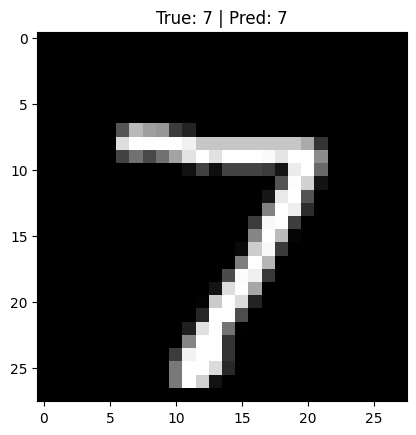

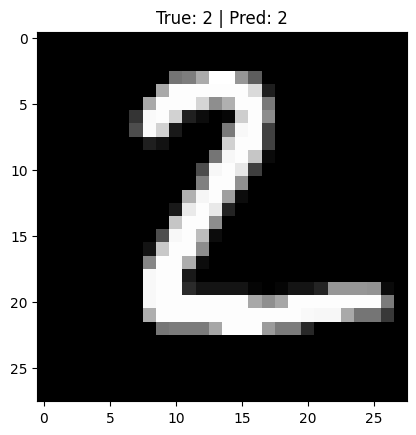

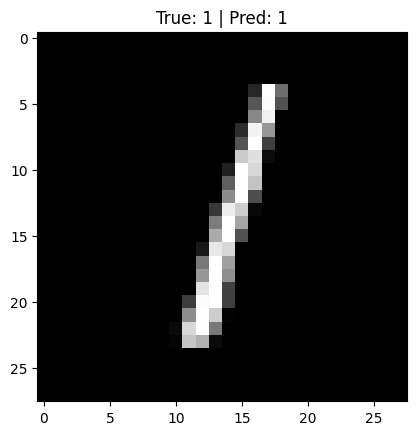

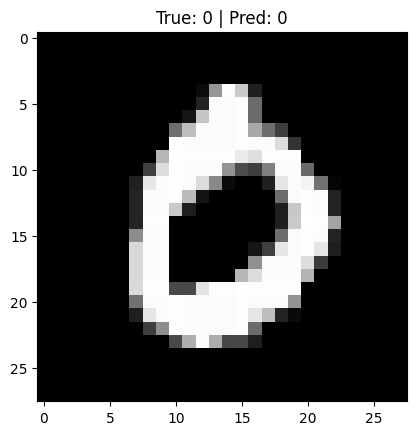

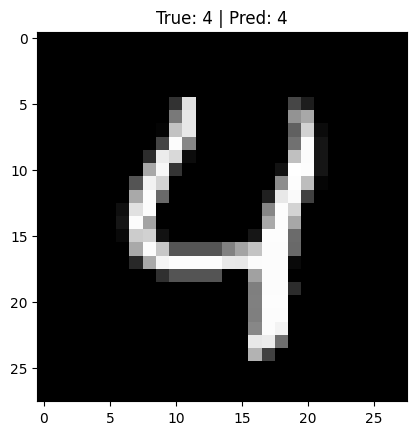

In [9]:
test_loss, test_acc = model.evaluate(X_test, Y_test)
print("Test Accuracy:", test_acc)

# Predictions
predictions = model.predict(X_test[:5])
for i in range(5):
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"True: {np.argmax(Y_test[i])} | Pred: {np.argmax(predictions[i])}")
    plt.show()


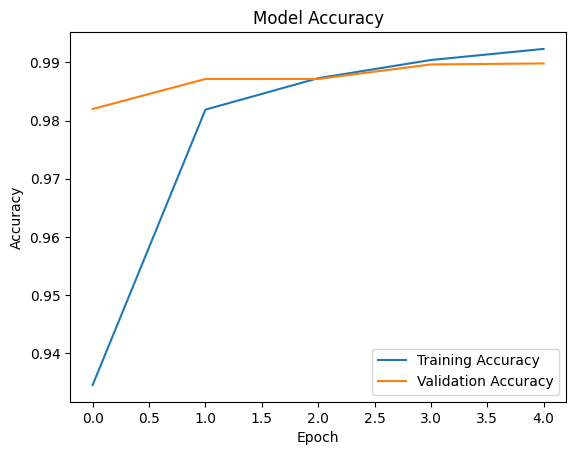

In [10]:
# Plot training and validation accuracy
plt.plot(history_1.history['accuracy'], label='Training Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

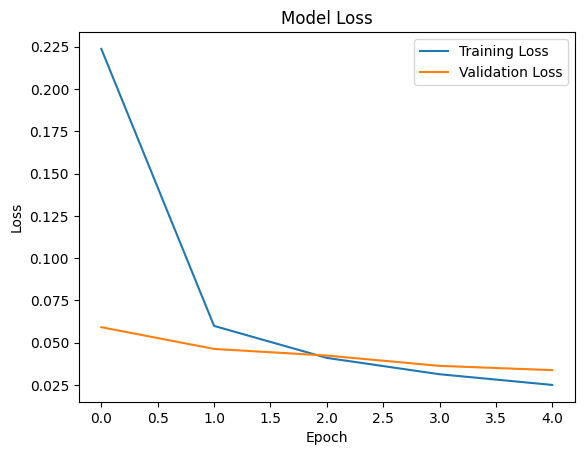

In [11]:
# Plot training and validation loss
plt.plot(history_1.history['loss'], label='Training Loss')
plt.plot(history_1.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


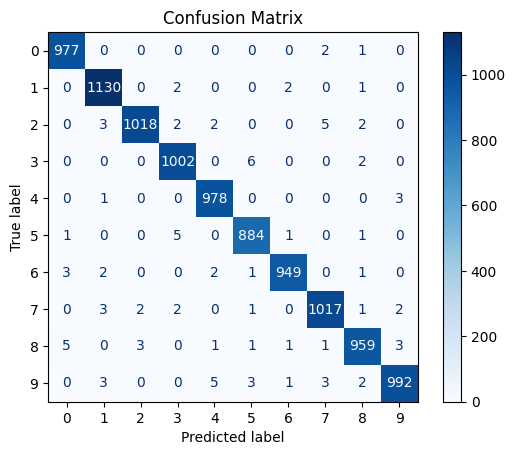

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions for the test set
Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(Y_true, Y_pred_classes)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()